# Lesson 2: Sampling Distributions, Errors, and Power

**Course:** hypothesis_testing_and_statistical_inference  
**Prerequisites:** Basic Python and descriptive statistics

This lesson follows a repeatable workflow: define the question, encode the design,
check assumptions, estimate the effect, quantify uncertainty, test the claim, and
communicate both statistical and practical meaning.


## Learning objectives

1. Use sampling distributions to explain standard errors and critical regions
2. Relate alpha, effect size, sample size, variability, and power
3. Estimate power by simulation
4. Recognize optional stopping and post-hoc power as poor analysis practices


## Setup

Run this cell first. Every example uses a fixed random seed so results are reproducible.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Work whether the kernel starts in the course root or a level folder.
working_dir = Path.cwd()
COURSE_ROOT = working_dir if (working_dir / "data").exists() else working_dir.parent
DATA_DIR = COURSE_ROOT / "data"

rng = np.random.default_rng(20260920)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.precision", 4)


## 2.1 Two kinds of decision error

| Reality | Do not reject $H_0$ | Reject $H_0$ |
|---|---|---|
| $H_0$ true | correct | Type I error ($\alpha$) |
| Meaningful alternative true | Type II error ($\beta$) | correct (power $=1-\beta$) |

Power is the long-run probability that a planned procedure rejects $H_0$ for a specified true effect.
It increases with larger effects, larger samples, lower noise, and (at a cost) larger $\alpha$.


In [2]:
# Empirical power simulation based on the real ANES age distribution.
anes = pd.read_csv(DATA_DIR / "anes96_clean.csv")
age_pool = anes["age_years"].dropna().to_numpy()
age_sd = age_pool.std(ddof=1)

def empirical_power(effect, n, alpha=.05, repetitions=1500):
    """Resample real ages and add a planned standardized shift to one group."""
    rejections = 0
    for _ in range(repetitions):
        control = rng.choice(age_pool, size=n, replace=True)
        treatment = rng.choice(age_pool, size=n, replace=True) + effect*age_sd
        p = stats.ttest_ind(control, treatment, equal_var=False).pvalue
        rejections += p < alpha
    return rejections/repetitions

rows = []
for effect in [0.0, 0.2, 0.5, 0.8]:
    for n in [10, 20, 40, 80]:
        rows.append({"standardized effect": effect, "n per group": n,
                     "rejection rate": empirical_power(effect, n)})
power_table = pd.DataFrame(rows)
power_table.pivot(index="n per group", columns="standardized effect", values="rejection rate")


standardized effect,0.0,0.2,0.5,0.8
n per group,,,,
10,0.0527,0.0733,0.1633,0.3927
20,0.0427,0.0960,0.3140,0.6853
40,0.0480,0.1427,0.6107,0.9467
80,0.0480,0.2360,0.8760,0.9980


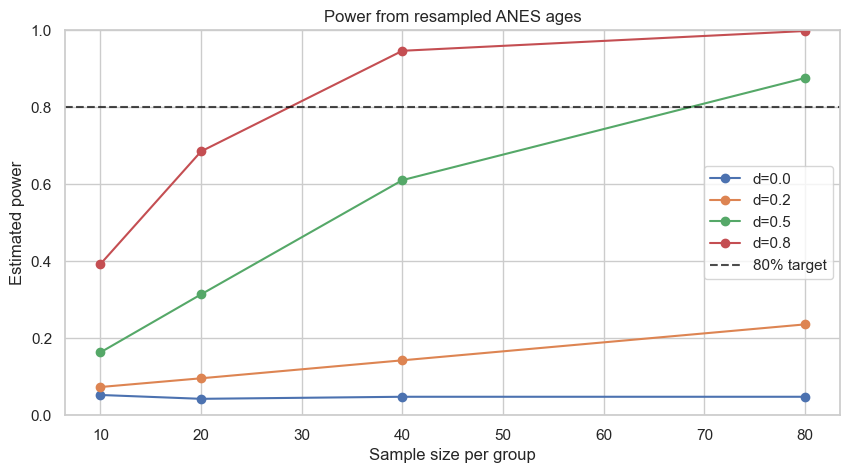

In [3]:
fig, ax = plt.subplots()
for effect, group in power_table.groupby("standardized effect"):
    ax.plot(group["n per group"], group["rejection rate"], marker="o", label=f"d={effect}")
ax.axhline(.80, color="black", linestyle="--", alpha=.7, label="80% target")
ax.set(xlabel="Sample size per group", ylabel="Estimated power",
       ylim=(0, 1), title="Power from resampled ANES ages")
ax.legend()
plt.show()


## 2.2 Planning before data collection

Power calculations need a **minimum effect of practical interest**, not the effect observed in the same
noisy dataset. The planning effect should come from domain requirements, credible prior studies, or a
smallest effect that would change a decision.

Optional stopping—repeatedly testing and stopping as soon as $p<.05$—raises the false-positive rate.
Pre-specify the sample size or use a valid sequential design.


In [4]:
from statsmodels.stats.power import TTestIndPower

# Use the observed age contrast only as a transparent planning illustration.
dole = anes.loc[anes["expected_vote"] == "Dole", "age_years"].to_numpy()
clinton = anes.loc[anes["expected_vote"] == "Clinton", "age_years"].to_numpy()
pooled_sd = np.sqrt(((len(dole)-1)*dole.var(ddof=1) + (len(clinton)-1)*clinton.var(ddof=1)) /
                    (len(dole)+len(clinton)-2))
observed_d = abs((dole.mean()-clinton.mean())/pooled_sd)

analysis = TTestIndPower()
required = analysis.solve_power(effect_size=observed_d, alpha=.05, power=.80, ratio=1)
achieved = analysis.power(effect_size=observed_d, nobs1=np.ceil(required), alpha=.05, ratio=1)
print(f"Observed ANES age effect size: d={observed_d:.3f}")
print(f"Illustrative required n per group: {np.ceil(required):.0f}")
print(f"Achieved power after rounding: {achieved:.3f}")


Observed ANES age effect size: d=0.109
Illustrative required n per group: 1325
Achieved power after rounding: 0.800


## Worked example and interpretation

### What the analysis does

The power table resamples observed ANES ages to build two independent groups, then adds a *planned artificial shift* to one group. Each entry is the fraction of 1,500 repeated samples in which Welch's test rejects at alpha 0.05. When the added effect is zero, rejection stays near 0.05 across group sizes; this checks the simulated Type I error. For a standardized shift of 0.5, estimated power rises from 0.163 with 10 observations per group to 0.876 with 80. For a smaller shift of 0.2, even 80 per group gives only 0.236 estimated power. The plotted curves visualize these same design tradeoffs.

### What the planning calculation means

A separate illustration measures an ANES age contrast between expected-vote groups and uses its observed standardized difference, 0.109, as a provisional target. A two-sided 80% power calculation gives about 1,325 observations **per group** under its model. This is not the power of the completed ANES analysis and is not a recommended sample size: a future study must choose the smallest substantively important effect *before* collecting outcome data. Changing variability, allocation, alpha, or the target effect changes the required sample size.

## Practice and solution

**Practice.** Name two defensible ways to choose an effect for a priori power analysis.

<details><summary>Solution</summary>

Use a smallest effect that would change a scientific or business decision, or use a conservative
estimate from high-quality prior evidence. Do not select the observed effect from a small pilot as if it
were known precisely; use sensitivity analysis across plausible values instead.
</details>

## Key takeaways

- Alpha controls false positives only under the planned procedure.
- Power is tied to a specific alternative and must be planned prospectively.
- Simulation is a flexible power tool when formulas do not match the design.


## Reproducibility checklist

- State the population, outcome, groups, and sampling unit.
- State $H_0$, $H_1$, alpha, and whether the test is one- or two-sided before looking at results.
- Verify independence from the design; use plots and diagnostics for distributional assumptions.
- Report the estimate, confidence interval, effect size, test statistic, degrees of freedom, and exact p-value.
- Separate statistical evidence from practical importance and acknowledge design limitations.
